In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
df = pd.read_csv("Financial Sample_CSV.csv")
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,1618.5,$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01-01-2014,1,January,2014
1,Government,Germany,Carretera,None,1321.0,$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01-01-2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.0,$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01-06-2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.0,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01-06-2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.0,$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01-06-2014,6,June,2014


In [20]:
df.shape

(700, 16)

In [21]:
df.describe(include='all')

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
count,700,700,700,700,700.000000,700,700,700,700,700,700,700,700,700.000000,700,700.000000
unique,5,5,6,4,NaN,6,7,550,515,559,545,557,16,NaN,12,NaN
top,Government,Canada,Paseo,High,NaN,$10.00,$20.00,"$37,050.00",$-,"$20,794.80","$17,430.00",$-,01-06-2014,NaN,October,NaN
freq,300,140,202,245,NaN,202,100,3,53,2,4,5,70,NaN,140,NaN
mean,NaN,NaN,NaN,NaN,1608.294286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.900000,NaN,2013.750000
std,NaN,NaN,NaN,NaN,867.427859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.377321,NaN,0.433322
min,NaN,NaN,NaN,NaN,200.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,2013.000000
25%,NaN,NaN,NaN,NaN,905.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.750000,NaN,2013.750000
50%,NaN,NaN,NaN,NaN,1542.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,2014.000000
75%,NaN,NaN,NaN,NaN,2229.125000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.250000,NaN,2014.000000


In [22]:
df.columns

Index(['Segment', 'Country', ' Product ', ' Discount Band ', 'Units Sold',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number',
       ' Month Name ', 'Year'],
      dtype='object')

In [23]:
df.columns = df.columns.str.strip().str.replace(' ','_')
df.columns

Index(['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold',
       'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name',
       'Year'],
      dtype='object')

In [31]:
df['Manufacturing_Price'].unique()
df['Sale_Price'].unique()
df['Gross_Sales'].unique()
df['Discounts'].unique()
df['COGS'].unique()
df['Profit'].unique()
df['Year'].unique()

array([2014, 2013], dtype=int64)

In [32]:
df['Manufacturing_Price'].unique()

array([' $3.00 ', ' $5.00 ', ' $10.00 ', ' $120.00 ', ' $250.00 ',
       ' $260.00 '], dtype=object)

In [39]:
df.isnull().sum()

Segment                 0
Country                 0
Product                 0
Discount_Band           0
Units_Sold              0
Manufacturing_Price     0
Sale_Price              0
Gross_Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month_Number            0
Month_Name              0
Year                    0
Manufacturing_Price2    0
dtype: int64

In [43]:
df['Manufacturing_Price2'] = df['Manufacturing_Price'].str.replace('[$, ]','',regex=True)
df['Manufacturing_Price2'] = pd.to_numeric(df['Manufacturing_Price2'],errors='coerce')

In [44]:
df['Manufacturing_Price2'].unique()

array([  3.,   5.,  10., 120., 250., 260.])

In [48]:
for col in ['Sale_Price','Gross_Sales','Discounts','Sales','COGS','Profit']:
    df[col] = df[col].replace(r'[$, ]','',regex=True)
    df[col] = pd.to_numeric(df[col],errors = 'coerce')
    


In [52]:
for u in df['Sale_Price'].unique():
    print(u)

20.0
15.0
350.0
12.0
125.0
300.0
7.0


In [55]:
df['Profit_Margin'] = (df['Profit'] / df['Sales'])*100

In [57]:
df['Revenue_Buckets'] = pd.cut(df['Sales'], bins=[0,50000,200000,500000,1000000],labels=['Low','Medium','High','Very High'])

In [58]:
df[['Sales','Revenue_Buckets']]

,Sales,Revenue_Buckets
0,32370.00,Low
1,26420.00,Low
2,32670.00,Low
3,13320.00,Low
4,37050.00,Low
...,...,...
695,631125.00,Very High
696,139230.00,Medium
697,8139.60,Low
698,4301.85,Low


In [59]:
df['Profit_Bucket'] = pd.qcut(df['Profit'],4, labels=['Low','Medium','High','Top'])

In [60]:
df[['Profit','Profit_Bucket']]

,Profit,Profit_Bucket
0,16185.00,High
1,13210.00,High
2,10890.00,Medium
3,4440.00,Medium
4,12350.00,High
...,...,...
695,12375.00,High
696,2730.00,Low
697,1299.60,Low
698,686.85,Low


In [62]:
df.groupby('Month_Name')['Sales'].sum().sort_values()

Month_Name
March          5586859.87
August         5864622.42
May            6210211.06
January        6607761.69
April          6964775.08
February       7297531.39
July           8102920.19
June           9518893.82
September     10882697.27
November      12651417.50
December      17367228.98
October       21671431.02
Name: Sales, dtype: float64

In [63]:
df.groupby('Segment')['Sales'].sum().sort_values()

Segment
Channel Partners     1800593.64
Midmarket            2381883.09
Enterprise          19611694.38
Small Business      42427918.50
Government          52504260.68
Name: Sales, dtype: float64

In [64]:
df.groupby('Product')['Sales'].sum().sort_values()

Product
Carretera     13815307.89
Montana       15390801.88
Amarilla      17747116.07
Velo          18250059.47
VTT           20511921.02
Paseo         33011143.96
Name: Sales, dtype: float64

In [67]:
df.groupby('Country')[['Sales','Profit']].sum()

,Sales,Profit
Country,,
Canada,24887654.89,3693717.64
France,24354172.29,3906754.54
Germany,23505340.82,3820885.07
Mexico,20949352.11,3053223.11
United States of America,25029830.18,3196443.18


In [68]:
df.groupby('Segment')['Profit'].sum().nlargest(3)

Segment
Government          11388173.18
Small Business       4143168.50
Channel Partners     1316803.14
Name: Profit, dtype: float64

In [78]:
f = df.groupby('Segment')['Profit'].sum().sort_values()

In [72]:
df.groupby('Country')['Profit'].sum().nsmallest(3)

Country
Mexico                      3053223.11
United States of America    3196443.18
Canada                      3693717.64
Name: Profit, dtype: float64

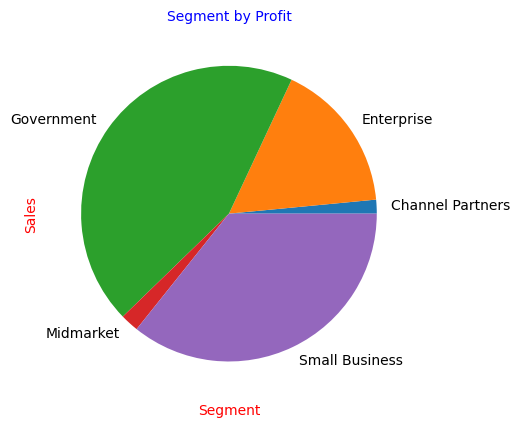

In [77]:
df.groupby('Segment')['Sales'].sum().plot(kind='pie')
plt.title("Segment by Profit", color='blue', fontsize=10)
plt.xlabel('Segment', color='red')
plt.ylabel('Sales', color='red')
plt.xticks(rotation=40)
plt.show()

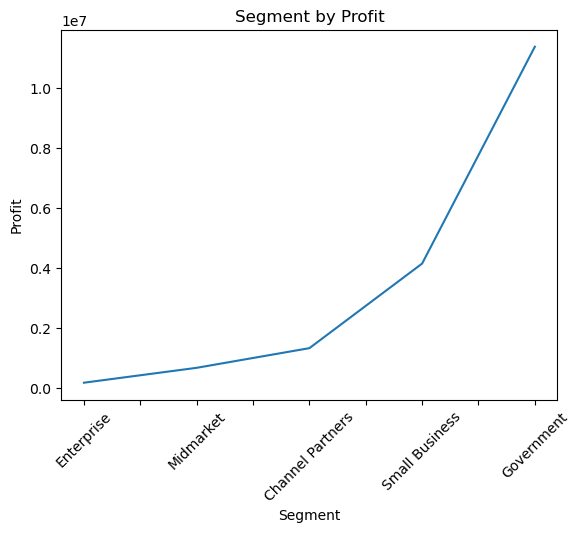

In [82]:
f.plot(kind='line')
plt.title("Segment by Profit")
plt.xticks(rotation=45)
plt.xlabel("Segment")
plt.ylabel("Profit")
plt.show()

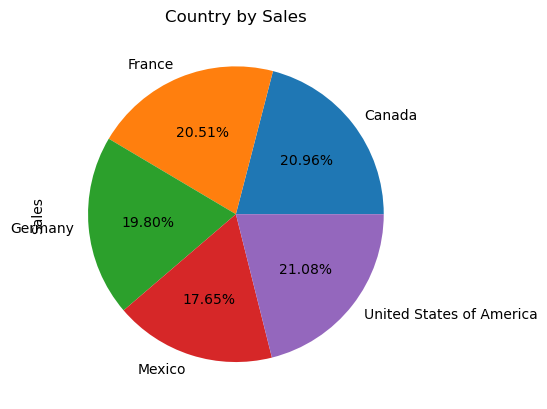

In [92]:
df.groupby('Country')['Sales'].sum().plot(kind='pie', autopct='%1.2f%%')
plt.title("Country by Sales")

plt.show()